The value of r-squared is 0.9953871470455031 .Hence,it is a good fit
Chi-squared value is 48.884591941032774
Critical value 352.42464991832384
It is a good fit
y0= 6.992767322850557
The damping constant is, b= 0.02994407645011484
The value of the angular frequency is, w= 0.9997791893322887
The phase angle, phi= 0.03540077578768372


C:\Users\rsrut\AppData\Local\Temp\ipykernel_17740\4250501387.py:13: RuntimeWarning: overflow encountered in exp
  return x0 * np.exp(-b * t) * np.cos(w * t + phi)+ y0


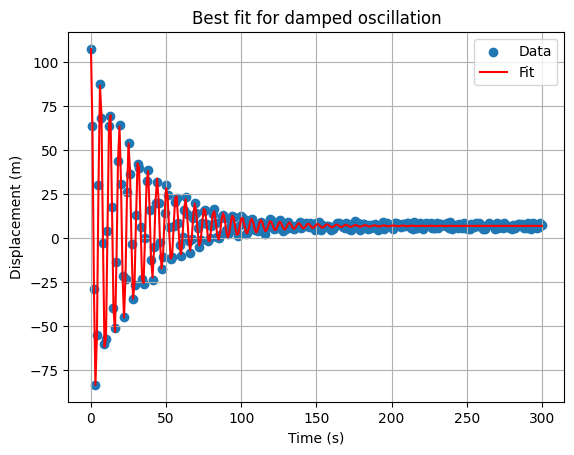

In [98]:
from scipy.optimize import curve_fit 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2


df = pd.read_csv('Damp-vibration_dataset.csv')
t = df['time (s)'].values 
y = df['displacement (m)'].values

def dampedoscillator(t, x0, b, w, phi, y0) :
    return x0 * np.exp(-b * t) * np.cos(w * t + phi)+ y0

params, covariance = curve_fit(dampedoscillator, t, y)
x0, b, w, phi, y0 = params[0],params[1],params[2], params[3], params[4]

y1 = dampedoscillator(t, x0, b, w, phi,y0)
tss = np.sum((y- np.mean(y1))**2)
rss = np.sum((y-y1)**2)

r_squared = 1- (rss/tss)

print("The value of r-squared is" , r_squared, ".Hence,it is a good fit")


df= len(t)- 1
residuals = y- y1
chi2_stat = np.sum(residuals**2/y1)
critical_value = chi2.ppf(0.98, df)

print("Chi-squared value is" , chi2_stat)
print("Critical value", critical_value)

if chi2_stat< critical_value:
    print("It is a good fit")
else: 
    print("It is not a good fit")

print("y0=", y0)
print("The damping constant is, b=", b)
print("The value of the angular frequency is, w=", abs(w))
print("The phase angle, phi=", phi)

plt.scatter(t,y, label= 'Data')
plt.plot(t, dampedoscillator(t, x0, b, w, phi, y0), color= "red",label='Fit')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Best fit for damped oscillation')
plt.legend()
plt.grid(True)
plt.show()


